IMPORTING LIBRARIES AND MODULES

In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import urllib.request
import zipfile
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from scipy.linalg import svd

Retrieving data from GitHub repo

In [3]:
url = "https://github.com/neeravbhuyan/GhostFaces/archive/refs/heads/main.zip"
urllib.request.urlretrieve(url, "GhostFaces.zip")

with zipfile.ZipFile("GhostFaces.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

data_dir = "./GhostFaces-main/grayfaces"

PROCESSING WITH THE DATA

In [4]:
image_vectors = []
labels = []

IMG_HEIGHT, IMG_WIDTH = 112, 92

for filename in sorted(os.listdir(data_dir)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        # Split filename like "female.anpage.1.jpg" -> label is "anpage"
        parts = filename.split('.')
        person_name = parts[1] if len(parts) >= 3 else parts[0]
        
        img_path = os.path.join(data_dir, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            # Resize and flatten to 1D vector of length (IMG_HEIGHT * IMG_WIDTH)
            img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            image_vectors.append(img_resized.flatten())
            labels.append(person_name)

# Convert to arrays: X shape is (Total_Images, N^2)
X = np.array(image_vectors, dtype=np.float32)
y = np.array(labels)

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f"Total images loaded is {X.shape[0]}")
print(f"Feature vector length is {X.shape[1]}")
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Total images loaded is 50
Feature vector length is 10304
Training set: (40, 10304), Testing set: (10, 10304)


CENTERING THE FACES

Shape of mean face vector: (10304,)
Shape of testing data after centering: (40, 10304)


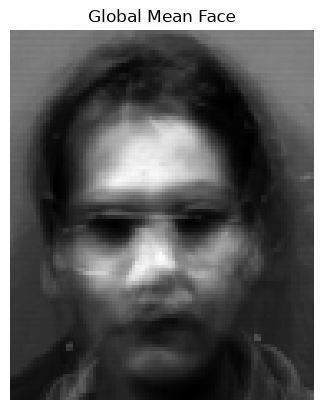

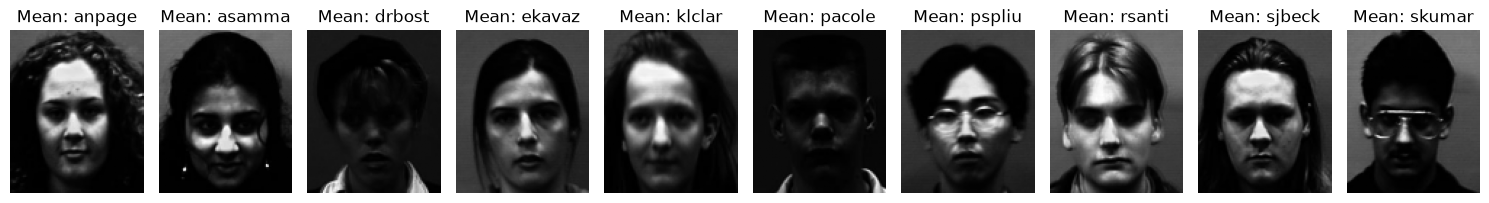

In [5]:
# Average face vector for entire training sample
global_mean_face = np.mean(X_train, axis = 0)

# Centering the data matrices
X_train_centered = X_train - global_mean_face
X_test_centered = X_test - global_mean_face

print(f"Shape of mean face vector: {global_mean_face.shape}")
print(f"Shape of testing data after centering: {X_train_centered.shape}")

# Visualizing global mean face
plt.imshow(global_mean_face.reshape(IMG_HEIGHT,IMG_WIDTH), cmap = "gray")
plt.title("Global Mean Face")
plt.axis("off")
plt.show()


# per-person mean faces
unique_people = np.unique(y_train)
person_means = {}

for person in unique_people:
    # Filter training images belonging to this person
    person_images = X_train[y_train == person]
    # Calculating average face for this individual
    person_means[person] = np.mean(person_images, axis = 0)

# Visualizing mean face for each person
plt.figure(figsize=(15, 3))
for i, person in enumerate(unique_people):
    plt.subplot(1, len(unique_people), i + 1)
    plt.imshow(person_means[person].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"Mean: {person}")
    plt.axis('off')
plt.tight_layout()
plt.show()

APPLYING SINGULAR VALUE DECOMPOSITION (SVD) TO FIND EIGNEFACES

Matrix A shape: (10304, 40)
U shape: (10304, 40), S shape: (40,), Vt shape: (40, 40)
Retained eigenfaces shape: (10304, 7)
Variance retained: 90.54%


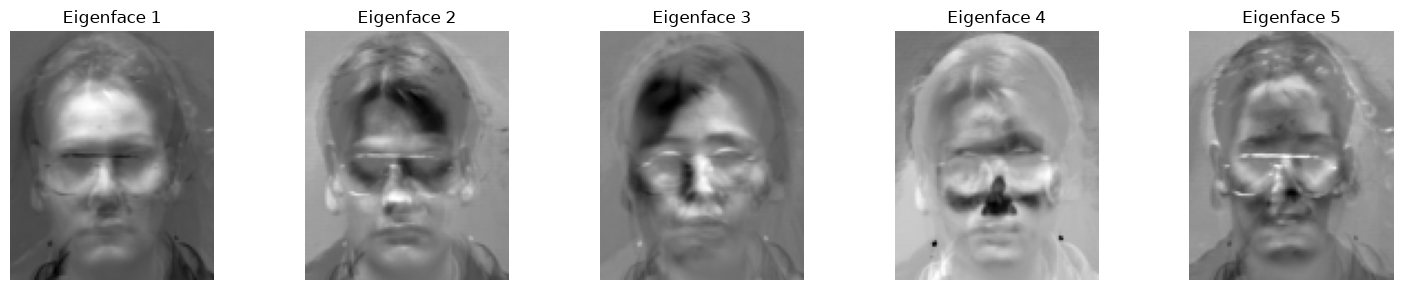

In [6]:
# Dimensionality reduction via SVD

A = X_train_centered.T

# comptuting the SVD (A = U*sigma*Vt)
U, S, Vt = svd(A, full_matrices = False)

# Select the smallest number of eigenfaces that retains at least 90% of the variance
explained_variance_ratio = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance_ratio)
M_prime = np.searchsorted(cumulative_variance, 0.90) + 1
eigenfaces = U[:, :M_prime]  # shape = N^2 x M_prime

print(f"Matrix A shape: {A.shape}")
print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Retained eigenfaces shape: {eigenfaces.shape}")
print(f"Variance retained: {cumulative_variance[M_prime - 1] * 100:.2f}%")

# Visualizing the top 5 eigenfaces
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape column vector back to 2D image
    plt.imshow(eigenfaces[:, i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"Eigenface {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

EXTRACTING FEATURE-WEIGHT VECTORS BY PROJECTING ONTO EIGENFACES

In [7]:
W_train = X_train_centered @ eigenfaces
W_test = X_test_centered @ eigenfaces

print(f"Training weights shape: {W_train.shape}")
print(f"Testing weights shape: {W_test.shape}")


Training weights shape: (40, 7)
Testing weights shape: (10, 7)


INITIALIZING SVM CLASSIFIER AND MODEL TRAINING

In [8]:
# A 'linear' kernel is often a strong baseline for PCA-reduced image data, 
# though 'rbf' (Radial Basis Function) is also highly effective.
svm_classifier = SVC(kernel='linear', random_state=42)

#Train the model using the 7D training weights and original labels
svm_classifier.fit(W_train, y_train)

#Predict labels for the testing weights
y_pred = svm_classifier.predict(W_test)

EVALUATE THE CLASSIFICATION PERFORMANCE 

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Classification Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

SVM Classification Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      anpage       1.00      1.00      1.00         1
      asamma       1.00      1.00      1.00         1
      drbost       1.00      1.00      1.00         1
      ekavaz       1.00      1.00      1.00         1
      klclar       1.00      1.00      1.00         1
      pacole       1.00      1.00      1.00         1
      pspliu       1.00      1.00      1.00         1
      rsanti       1.00      1.00      1.00         1
      sjbeck       1.00      1.00      1.00         1
      skumar       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



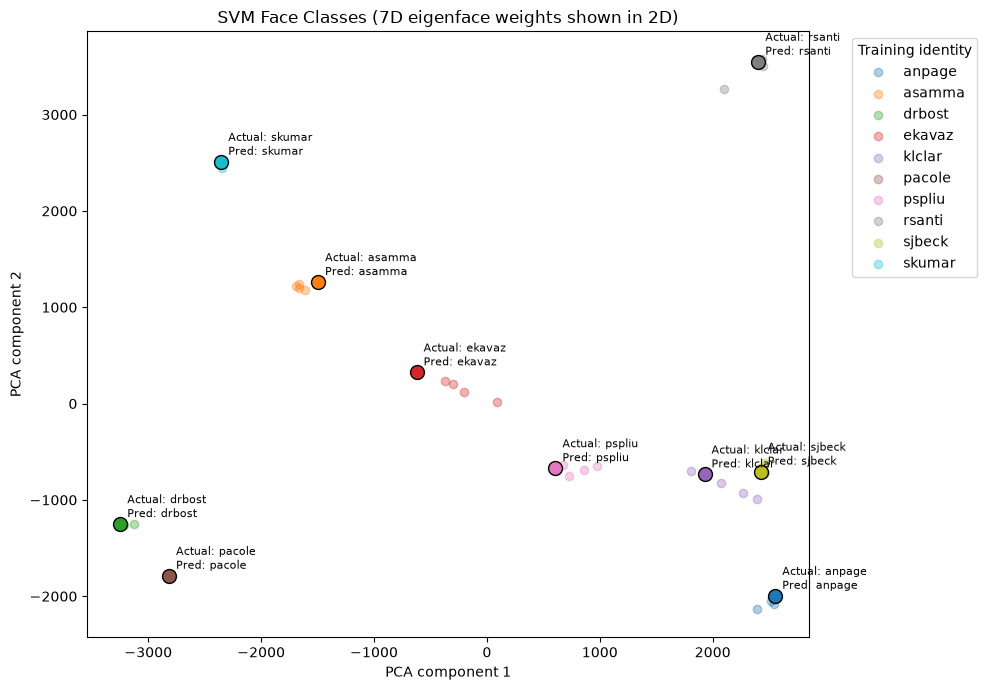

In [14]:
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Reduce the 7D weights to 2D for plotting only
pca_2d = PCA(n_components=2)
W_train_2d = pca_2d.fit_transform(W_train)
W_test_2d = pca_2d.transform(W_test)

fig, ax = plt.subplots(figsize=(10, 7))

# Show training images as faint points, colored by identity
people = np.unique(y_train)
colors = plt.cm.tab10(np.linspace(0, 1, len(people)))
color_map = dict(zip(people, colors))

for person in people:
    mask = y_train == person
    ax.scatter(
        W_train_2d[mask, 0], W_train_2d[mask, 1],
        color=color_map[person], label=person, alpha=0.35
    )

# Show test images as larger points, labeled with predicted identity
for i, (x, y) in enumerate(W_test_2d):
    ax.scatter(x, y, color=color_map[y_pred[i]], edgecolor="black", s=100)
    ax.annotate(f"Actual: {y_test[i]}\nPred: {y_pred[i]}",
                (x, y), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.set_title("SVM Face Classes (7D eigenface weights shown in 2D)")
ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
ax.legend(title="Training identity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

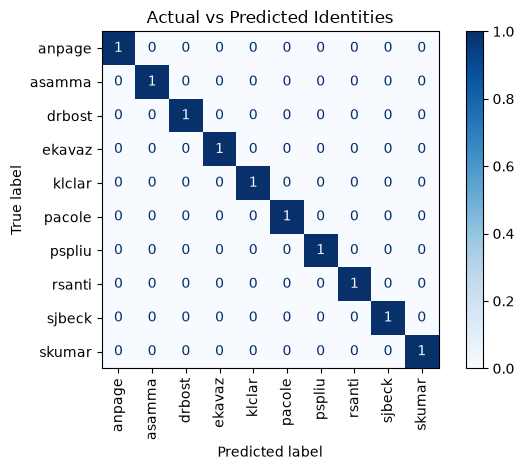

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical",
    cmap="Blues"
)
plt.title("Actual vs Predicted Identities")
plt.tight_layout()
plt.show()